# Kicked Ising Model on IBM Eagle (127 Qubits)

This notebook reproduces the quantum utility experiment from
[Kim et al., *Nature* **618**, 500–505 (2023)](https://doi.org/10.1038/s41586-023-06096-3)
using the **Majorana Propagation Simulator** (MP) as a classical reference.

## Scientific Background

The **Kicked Ising model** is a periodically driven (Floquet) spin system defined on a graph
$G = (V, E)$. One Trotter layer consists of two unitaries applied in sequence:

$$U(\theta) = U_X(\theta)\, U_{ZZ}$$

where

$$U_{ZZ} = \prod_{\langle i,j \rangle \in E} e^{-i\frac{\pi}{4} Z_i Z_j}, \qquad U_X(\theta) = \prod_{i \in V} e^{-i\frac{\theta}{2} X_i}$$

After $L$ layers starting from $|0\rangle^{\otimes N}$ the state is
$|\psi_L(\theta)\rangle = [U(\theta)]^L |0\rangle^{\otimes N}$
and we measure the single-site expectation value $\langle Z_q \rangle$ of 
the Pauli-$Z$ operator on qubit $q$ as a function of $\theta$.

The graph is the **IBM Eagle (r3) Heavy-Hex** connectivity: 127 qubits on
a heavy hexagonal lattice with 144 edges. The experiment used $L = 20$ Trotter layers.

## Simulation Strategy

MP works in the **Heisenberg picture**: instead of propagating the $2^{127}$-dimensional
state vector, it propagates the chosen observable backward through the circuit in the
Majorana-string basis. Strings beyond a maximum length `cutoff` are dropped, giving a
controllable approximation whose cost is independent of the Hilbert-space dimension.


In [ ]:
from __future__ import annotations

import time

import numpy as np

from monoprop import Circuit, Exp, PauliPropagator
from monoprop.pauli import Pauli, PauliOperator

## 1. Configuration

`NQ`, `NL`, and `N_ANGLES` fix the system size, circuit depth, and sweep resolution.
Reduce `N_ANGLES` (to 5–10) or `cutoff` (to 4) in §5 for a quicker run on a laptop.

In [2]:
NQ = 127  # number of qubits (IBM Eagle r3)
NL = 20  # number of Trotter layers
N_ANGLES = (
    20  # sweep points from 0 to π/2; reduce to 5–10 for a quicker result on a laptop
)

## 2. Heavy-Hex Topology

The IBM Eagle processor uses a **heavy hexagonal lattice**: qubits sit on the vertices
of a graph where each node has degree ≤ 3. The lattice has seven alternating horizontal
chains (rows 0–6) connected by short vertical "bridge" qubits.

![IBM Eagle Heavy-Hex topology — 127 qubits, 144 edges. Qubit 62 (red) is the measured observable.](heavy_hex_topology.png)

The coupling map below lists all 144 pairs $(i, j)$ with $i < j$.
It can also be obtained via `FakeEagle().coupling_map` from `qiskit_ibm_runtime`.


In [3]:
# IBM Eagle 127-qubit heavy-hex coupling map (i < j for all pairs).
# Can also be loaded via: FakeEagle().coupling_map from qiskit_ibm_runtime.
HEAVY_HEX_TOPOLOGY: list[tuple[int, int]] = [
    # Row 0 (qubits 0–13): horizontal chain
    (0, 1),
    (1, 2),
    (2, 3),
    (3, 4),
    (4, 5),
    (5, 6),
    (6, 7),
    (7, 8),
    (8, 9),
    (9, 10),
    (10, 11),
    (11, 12),
    (12, 13),
    # Bridge qubits 14–17 connect row 0 → row 1
    (0, 14),
    (4, 15),
    (8, 16),
    (12, 17),
    (14, 18),
    (15, 22),
    (16, 26),
    (17, 30),
    # Row 1 (qubits 18–32): horizontal chain
    (18, 19),
    (19, 20),
    (20, 21),
    (21, 22),
    (22, 23),
    (23, 24),
    (24, 25),
    (25, 26),
    (26, 27),
    (27, 28),
    (28, 29),
    (29, 30),
    (30, 31),
    (31, 32),
    # Bridge qubits 33–36 connect row 1 → row 2
    (20, 33),
    (24, 34),
    (28, 35),
    (32, 36),
    (33, 39),
    (34, 43),
    (35, 47),
    (36, 51),
    # Row 2 (qubits 37–51): horizontal chain
    (37, 38),
    (38, 39),
    (39, 40),
    (40, 41),
    (41, 42),
    (42, 43),
    (43, 44),
    (44, 45),
    (45, 46),
    (46, 47),
    (47, 48),
    (48, 49),
    (49, 50),
    (50, 51),
    # Bridge qubits 52–55 connect row 2 → row 3
    (37, 52),
    (41, 53),
    (45, 54),
    (49, 55),
    (52, 56),
    (53, 60),
    (54, 64),
    (55, 68),
    # Row 3 (qubits 56–70): horizontal chain  ← qubit 62 is measured
    (56, 57),
    (57, 58),
    (58, 59),
    (59, 60),
    (60, 61),
    (61, 62),
    (62, 63),
    (63, 64),
    (64, 65),
    (65, 66),
    (66, 67),
    (67, 68),
    (68, 69),
    (69, 70),
    # Bridge qubits 71–74 connect row 3 → row 4
    (58, 71),
    (62, 72),
    (66, 73),
    (70, 74),
    (71, 77),
    (72, 81),
    (73, 85),
    (74, 89),
    # Row 4 (qubits 75–89): horizontal chain
    (75, 76),
    (76, 77),
    (77, 78),
    (78, 79),
    (79, 80),
    (80, 81),
    (81, 82),
    (82, 83),
    (83, 84),
    (84, 85),
    (85, 86),
    (86, 87),
    (87, 88),
    (88, 89),
    # Bridge qubits 90–93 connect row 4 → row 5
    (75, 90),
    (79, 91),
    (83, 92),
    (87, 93),
    (90, 94),
    (91, 98),
    (92, 102),
    (93, 106),
    # Row 5 (qubits 94–108): horizontal chain
    (94, 95),
    (95, 96),
    (96, 97),
    (97, 98),
    (98, 99),
    (99, 100),
    (100, 101),
    (101, 102),
    (102, 103),
    (103, 104),
    (104, 105),
    (105, 106),
    (106, 107),
    (107, 108),
    # Bridge qubits 109–112 connect row 5 → row 6
    (96, 109),
    (100, 110),
    (104, 111),
    (108, 112),
    (109, 114),
    (110, 118),
    (111, 122),
    (112, 126),
    # Row 6 (qubits 113–126): horizontal chain
    (113, 114),
    (114, 115),
    (115, 116),
    (116, 117),
    (117, 118),
    (118, 119),
    (119, 120),
    (120, 121),
    (121, 122),
    (122, 123),
    (123, 124),
    (124, 125),
    (125, 126),
]

## 3. Observable and Reference Data

To characterise the dynamics we measure a single-site Pauli expectation value
$\langle P_q \rangle = \langle \psi_L(\theta) | P_q | \psi_L(\theta) \rangle$,
where $P_q \in \{X, Y, Z\}$ is a Pauli operator on qubit $q$.
Single-site observables are natural probes of Floquet thermalization: they
start near 1 at $\theta = 0$ (trivial evolution) and decay as $\theta$ increases
and the drive pushes the system toward a more scrambled state.

In the IBM experiment the chosen observable is $\langle Z_{62} \rangle$ — the Pauli-Z
expectation on qubit 62, which sits at the centre of row 3 in the heavy-hex lattice
and is therefore representative of the bulk dynamics rather than edge effects.

`ibm_mitigated_vals` contains the error-mitigated experimental values from the IBM paper,
sampled at 11 angles $\theta \in \{0, 0.1, \ldots, 0.8, 1.0, \pi/2\}$.


In [4]:
# Observable: Z on qubit 62 (centre of the heavy-hex lattice)
OBS_QUBIT = 62
obs_str = "I" * OBS_QUBIT + "Z" + "I" * (NQ - OBS_QUBIT - 1)
ham = {obs_str: 1.0}  # single-term "Hamiltonian" encoding ⟨Z_62⟩

# IBM hardware angles and error-mitigated values (Kim et al. 2023, Fig. 4b)
ibm_angles = np.array([0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.5707])
ibm_mitigated_vals = [
    1.01688859,
    1.00387483,
    0.95615886,
    0.95966435,
    0.83946763,
    0.81185907,
    0.54640995,
    0.45518584,
    0.19469377,
    0.01301832,
    0.01016334,
]

## 4. Kicked Ising Circuit

The circuit is composed of two layer types applied `NL` times in sequence:

- **X layer** — single-qubit rotations $e^{-i\theta/2\, X} = R_X(\theta)$ on all $N$ qubits.
- **ZZ layer** — simultaneous $e^{-i(\pi/4) Z_i Z_j}$ gates on all topology edges.
  The coupling strength $J = \pi/4$ is fixed; only $\theta$ is swept.

`kicked_ising_circuit` assembles `NL` alternating X + ZZ layer pairs into a Qiskit circuit.


In [ ]:
def xlayer(nq: int, t: float) -> tuple[list, list]:
    """Single-qubit X rotations exp(-i t X) on all nq qubits.

    Returns the pure X generators and their matching angles as parallel lists.
    """
    gates = [Exp(PauliOperator({Pauli("X", i): 1.0}, num_qubits=nq)) for i in range(nq)]
    params = [-t for _ in range(nq)]
    return gates, params


def zzlayer(t: float, topology: list[tuple[int, int]]) -> tuple[list, list]:
    """Two-qubit ZZ interactions exp(-i t ZZ) on every edge in topology.

    Returns the pure ZZ generators and their matching angles as parallel lists.
    """
    gates = [
        Exp(PauliOperator({Pauli("ZZ", (i, j)): 1.0}, num_qubits=NQ))
        for i, j in topology
    ]
    params = [-t for _ in topology]
    return gates, params


def kicked_ising_circuit(
    theta: float,
    topology: list[tuple[int, int]] = HEAVY_HEX_TOPOLOGY,
    nq: int = NQ,
    nl: int = NL,
) -> Circuit:
    """Build the kicked-Ising Circuit for a given transverse-field angle.

    Each of the nl Trotter layers applies:
      1. exp(-i·θ/2·X) on all qubits  (X layer)
      2. exp(-i·π/4·ZZ) on all edges  (ZZ layer, fixed coupling J = π/4)

    Args:
        theta: Transverse-field rotation angle (swept from 0 to π/2).
        topology: Graph edges for the ZZ interactions.
        nq: Number of qubits.
        nl: Number of Trotter layers.

    Returns:
        Circuit encoding the full kicked-Ising evolution.
    """
    gates: list = []
    parameters: list = []
    for _ in range(nl):
        xg, xp = xlayer(nq, theta / 2)
        zg, zp = zzlayer(np.pi / 4, topology)
        gates.extend(xg)
        parameters.extend(xp)
        gates.extend(zg)
        parameters.extend(zp)

    return Circuit(
        gates=tuple(gates),
        parameters=parameters,
        initial_state=[],
    )

## 5. Simulation Setup

Here we define the parameters for the simulation.
We sweep `theta` over `N_ANGLES` evenly-spaced values from 0 to $\pi/2$, build one
kicked-Ising circuit per angle, and feed each straight to the `PauliPropagator`.

> **Runtime note:** with the default settings (`N_ANGLES=20`, `cutoff=8`, 127 qubits,
> 20 Trotter layers) the circuit-conversion and simulation steps can take tens of minutes
> on a laptop. For a quick test, set `N_ANGLES = 5` and `cutoff = 4` in the cells above.
> Note that `classical_expectations` (§7) is only valid for `N_ANGLES = 20`.


In [ ]:
theta_values = np.linspace(0, np.pi / 2, N_ANGLES)

circuits = [kicked_ising_circuit(t) for t in theta_values]

# convert ⟨Z_62⟩ to Majorana-string basis; the observable carries the qubit count
pauli_operator = PauliOperator(ham, num_qubits=NQ)

lower_atol = 1e-4  # prune strings with norm below this value
upper_atol = None  # no upper pruning
cutoff = 8  # maximum Majorana-string length; reduce to 4 for ~4× speedup

In [ ]:
# One PauliGate per Pauli evolution; the Pauli->Majorana mapping happens inside
# PauliPropagator.
gates = circuits[3].gates
len(gates)

## 6. Run the Simulation

For each $\theta$ angle, the simulator:

1. **Instantiates** `PauliPropagator` with $Z_{62}$ as the initial operator
   (Heisenberg picture — the operator is evolved backward, not the state).
2. **Propagates** the operator through all gates via `propagate`,
   building the truncated branch structure.
3. **Evaluates** $\langle Z_{62} \rangle = \langle 0 |\hat{O}(\boldsymbol{\theta})| 0 \rangle$
   via `mp.expectation_value()`, contracting against $|0\rangle^{\otimes N}$.

This cell takes around 1-2 minutes to run on a laptop. Individual step timing is also shown in the output.

In [ ]:
expectations = []

for pauli_circuit in circuits:
    # Step 1: initialise with ⟨Z_62⟩ as the starting operator.
    t_inst = time.time()
    mp = PauliPropagator(
        pauli_operator,
        pauli_circuit.initial_state,
        cutoff=cutoff,
        lower_atol=lower_atol,
        upper_atol=upper_atol,
    )
    t_inst = time.time() - t_inst

    # Step 2: propagate the operator backward (immediate contraction, no stored graph).
    t_evo = time.time()
    mp.propagate(pauli_circuit)
    t_evo = time.time() - t_evo

    # Step 3: evaluate ⟨Z_62⟩ = ⟨0| Ô(θ) |0⟩.
    t_expval = time.time()
    expectation = mp.expectation_value()
    t_expval = time.time() - t_expval

    expectations.append(expectation)
    print(
        f"⟨Z_62⟩ = {expectation:+.6f} | "
        f"size = {mp.size():5d} | "
        f"init {t_inst:.2f}s  evo {t_evo:.2f}s  eval {t_expval:.2f}s"
    )

## 8. Results: monoprop vs IBM

The plot overlays three datasets:

- **MP** (circles) — Majorana propagation simulation with rank cutoff `c = 8`.
- **IBM error-mitigated** (crosses, dotted) — hardware results from Kim et al. (2023),
  sampled at 11 angles using probabilistic error cancellation (PEC).

The classical expectation is the following: at $\theta = 0$ the state stays $|0\rangle^{\otimes N}$ and $\langle Z_{62} \rangle = 1$.
As $\theta \to \pi/2$ quantum fluctuations grow and the expectation decays to 0.

Good agreement between MP and the classical reference validates the rank-8 truncation.
Deviations from the IBM curve reflect residual hardware noise even after mitigation.

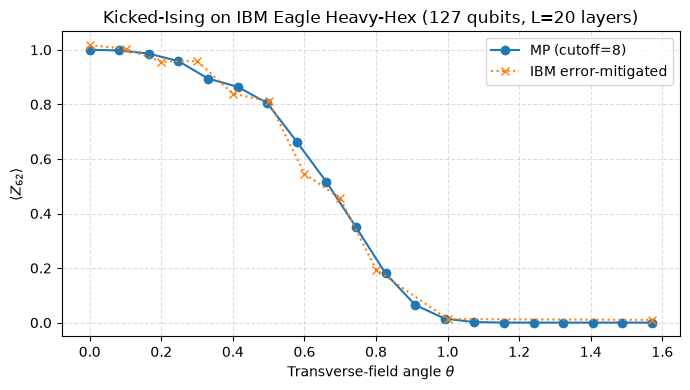

In [9]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(theta_values, expectations, marker="o", label=f"MP (cutoff={cutoff})")
ax.plot(
    ibm_angles,
    ibm_mitigated_vals,
    marker="x",
    linestyle=":",
    label="IBM error-mitigated",
)
ax.set_xlabel(r"Transverse-field angle $\theta$")
ax.set_ylabel(r"$\langle Z_{62} \rangle$")
ax.set_title("Kicked-Ising on IBM Eagle Heavy-Hex (127 qubits, L=20 layers)")
ax.legend()
ax.grid(True, which="both", ls="--", alpha=0.4)
plt.tight_layout()
plt.show()